In [1]:
# %%
# ============================================================
# COMPLETE RESULT ANALYSIS CODE
# For LightGCN + BPR experiments across datasets / layers / k
# ============================================================

import os
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
LOG_DIRS = {
    "movielens100k": "log/ml_100k/",
    "movielens1m": "log/ml_1m/",
    "amazonBeauty2m": "log/beauty2m/",
}

SAVE_DIR = "figures/result_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

# Optional: dataset statistics for density / threshold analysis
# Fill these with your real values if available.
DATASET_STATS = {
    "movielens100k": {
        "n_users": 943,
        "n_items": 1682,
        "n_edges": 100000,
    },
    "movielens1m": {
        "n_users": 6040,
        "n_items": 3706,
        "n_edges": 1000209,
    },
    "amazonBeauty2m": {
        "n_users": 12101,   # replace if your processed set differs
        "n_items": 249274,  # replace if your processed set differs
        "n_edges": 2023070, # replace if your processed set differs
    },
}

title_map = {
    "movielens100k": "MovieLens100K",
    "movielens1m": "MovieLens1M",
    "amazonBeauty2m": "AmazonBeauty2M"
}

In [2]:
# ------------------------------------------------------------
# HELPER: safe nested get
# ------------------------------------------------------------
def nested_get(d, keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

# ------------------------------------------------------------
# LOAD RESULTS
# ------------------------------------------------------------
def load_one_result(path):
    r = torch.load(path, map_location="cpu")

    config = r.get("config", {})
    timing = r.get("timing", {})
    test_result = r.get("test_result", {})
    memory = r.get("memory", {})

    dataset = config.get("dataset_name", "unknown_dataset")
    L = config.get("num_layers", None)
    k = config.get("num_samples_per_user", None)
    emb_dim = config.get("embedding_size", None)
    epochs = config.get("epochs", None)
    batch_size = config.get("batch_size", None)
    eval_batch_size = config.get("eval_batch_size", None)

    # Timing keys may vary slightly across files
    total_time = timing.get("total_training_time_seconds", np.nan)
    prop_time = timing.get("propagation_time_seconds", np.nan)

    # Try multiple possible names
    bpr_objective_time = (
        timing.get("bpr_objective_time_seconds", None)
        if "bpr_objective_time_seconds" in timing else
        timing.get("score_loss_time_seconds", np.nan)
    )

    forward_time = (
        timing.get("forward_total_time_seconds", None)
        if "forward_total_time_seconds" in timing else
        timing.get("bpr_forward_total_time_seconds", np.nan)
    )

    backward_time = timing.get("backward_step_time_seconds", np.nan)
    bpr_optimization_time = bpr_objective_time + backward_time
    eval_time = timing.get("evaluation_time_seconds", np.nan)
    avg_epoch_time = timing.get("average_epoch_time_seconds", np.nan)

    # Test metrics may also vary slightly
    test_p = (
        test_result.get("test_p", None)
        if "test_p" in test_result else
        nested_get(test_result, ["test_topks", "test_p"], np.nan)
    )
    test_r = (
        test_result.get("test_r", None)
        if "test_r" in test_result else
        nested_get(test_result, ["test_topks", "test_r"], np.nan)
    )
    test_n = (
        test_result.get("test_n", None)
        if "test_n" in test_result else
        nested_get(test_result, ["test_topks", "test_n"], np.nan)
    )

    test_bpr = test_result.get("BPR_loss", np.nan)
    test_reg = test_result.get("Reg_loss", np.nan)

    actual_mb = memory.get("actual_MB", {})
    theoretical_mb = memory.get("theoretical_MB", {})
    gpu_peak = memory.get("gpu_peak_MB", np.nan)
    epoch_mem = memory.get("epoch_log", np.nan)

    row = {
        "file": os.path.basename(path),

        "dataset": dataset,
        "L": L,
        "k": k,
        "embedding_size": emb_dim,
        "epochs": epochs,
        "batch_size": batch_size,
        "eval_batch_size": eval_batch_size,
        
        # timing
        "total_time": total_time,
        "prop_time": prop_time,
        "bpr_objective_time": bpr_objective_time,
        "forward_time": forward_time,
        "backward_time": backward_time,
        "bpr_optimization_time": bpr_optimization_time,
        "eval_time": eval_time,
        "avg_epoch_time": avg_epoch_time,

        # performance
        "precision": test_p,
        "recall": test_r,
        "ndcg": test_n,
        "test_bpr_loss": test_bpr,
        "test_reg_loss": test_reg,

        # final memory summary
        "gpu_peak_MB": gpu_peak,
        "R_all_csr_MB": actual_mb.get("R_all_csr", np.nan),
        "R_train_csr_MB": actual_mb.get("R_train_csr", np.nan),
        "split_train_MB": actual_mb.get("split_train", np.nan),
        "split_val_MB": actual_mb.get("split_val", np.nan),
        "split_test_MB": actual_mb.get("split_test", np.nan),
        "model_params_MB": actual_mb.get("model_params", np.nan),
        "norm_adj_gpu_MB": actual_mb.get("norm_adj_gpu", np.nan),

        # theoretical memory
        "theoretical_total_MB": theoretical_mb.get("total_MB", np.nan),
        "theoretical_embeddings_MB": theoretical_mb.get("embeddings_MB", np.nan),
        "theoretical_adj_values_MB": theoretical_mb.get("adj_values_MB", np.nan),
        "theoretical_adj_indices_MB": theoretical_mb.get("adj_indices_MB", np.nan),
        "theoretical_propagation_MB": theoretical_mb.get("propagation_MB", np.nan),
        "theoretical_adam_MB": theoretical_mb.get("adam_moments_MB", np.nan),
        "theoretical_grad_MB": theoretical_mb.get("gradients_MB", np.nan),

        # keep epoch memory log
        "epoch_log": epoch_mem,
    }

    # Derived actual total tracked memory
    row["actual_total_tracked_MB"] = np.nansum([
        row["R_all_csr_MB"],
        row["R_train_csr_MB"],
        row["split_train_MB"],
        row["split_val_MB"],
        row["split_test_MB"],
        row["model_params_MB"],
        row["norm_adj_gpu_MB"],
    ])

    return row


def load_results_from_dirs(log_dirs):
    rows = []

    for dataset_name, log_dir in log_dirs.items():
        if not os.path.exists(log_dir):
            print(f"[Warning] Log directory not found: {log_dir}")
            continue

        for f in os.listdir(log_dir):
            if f.endswith(".pkl"):
                path = os.path.join(log_dir, f)
                try:
                    row = load_one_result(path)
                    if row["dataset"] == "unknown_dataset":
                        row["dataset"] = dataset_name
                    rows.append(row)
                except Exception as e:
                    print(f"[Skip] Failed to load {path}: {e}")

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No experiment files were loaded.")

    df = df.sort_values(["dataset", "L", "k"]).reset_index(drop=True)

    # add dataset stats if available
    for stat_name in ["n_users", "n_items", "n_edges"]:
        df[stat_name] = df["dataset"].map(
            {d: DATASET_STATS.get(d, {}).get(stat_name, np.nan) for d in df["dataset"].unique()}
        )

    # graph density
    df["graph_density"] = df["n_edges"] / (df["n_users"] * df["n_items"])

    # average degree per user
    df["avg_user_degree"] = df["n_edges"] / df["n_users"]

    # time normalized by k
    df["time_per_k"] = df["total_time"] / df["k"]

    # performance efficiency
    df["recall_per_second"] = df["recall"] / df["total_time"]

    # memory ratio
    df["gpu_peak_per_k"] = df["gpu_peak_MB"] / df["k"]

    return df

In [3]:
# ------------------------------------------------------------
# MAIN EXECUTION
# ------------------------------------------------------------
df = load_results_from_dirs(LOG_DIRS)

print("\nLoaded experiment summary:")
print(df.columns)
df.head()


Loaded experiment summary:
Index(['file', 'dataset', 'L', 'k', 'embedding_size', 'epochs', 'batch_size',
       'eval_batch_size', 'total_time', 'prop_time', 'bpr_objective_time',
       'forward_time', 'backward_time', 'bpr_optimization_time', 'eval_time',
       'avg_epoch_time', 'precision', 'recall', 'ndcg', 'test_bpr_loss',
       'test_reg_loss', 'gpu_peak_MB', 'R_all_csr_MB', 'R_train_csr_MB',
       'split_train_MB', 'split_val_MB', 'split_test_MB', 'model_params_MB',
       'norm_adj_gpu_MB', 'theoretical_total_MB', 'theoretical_embeddings_MB',
       'theoretical_adj_values_MB', 'theoretical_adj_indices_MB',
       'theoretical_propagation_MB', 'theoretical_adam_MB',
       'theoretical_grad_MB', 'epoch_log', 'actual_total_tracked_MB',
       'n_users', 'n_items', 'n_edges', 'graph_density', 'avg_user_degree',
       'time_per_k', 'recall_per_second', 'gpu_peak_per_k'],
      dtype='object')


,file,dataset,L,k,embedding_size,epochs,batch_size,eval_batch_size,total_time,prop_time,...,epoch_log,actual_total_tracked_MB,n_users,n_items,n_edges,graph_density,avg_user_degree,time_per_k,recall_per_second,gpu_peak_per_k
0,result_amazonBeauty2m_1layers_1sample_allusers...,amazonBeauty2m,1,1,64,10,4096,2048,506.316926,0.664587,...,"[{'epoch': 0, 'ram_mb': 3109.47265625, 'gpu_al...",466.320992,12101,249274,2023070,0.000671,167.182051,506.316926,0.000045,5788.183594
1,result_amazonBeauty2m_1layers_5sample_allusers...,amazonBeauty2m,1,5,64,10,4096,2048,1403.556747,2.801714,...,"[{'epoch': 0, 'ram_mb': 3217.3046875, 'gpu_all...",466.320992,12101,249274,2023070,0.000671,167.182051,280.711349,0.000019,1187.184375
2,result_amazonBeauty2m_1layers_10sample_alluser...,amazonBeauty2m,1,10,64,10,4096,2048,2440.154325,4.535764,...,"[{'epoch': 0, 'ram_mb': 3353.98046875, 'gpu_al...",466.320992,12101,249274,2023070,0.000671,167.182051,244.015432,0.000011,612.158496
3,result_amazonBeauty2m_2layers_1sample_allusers...,amazonBeauty2m,2,1,64,10,4096,2048,587.091487,0.846609,...,"[{'epoch': 0, 'ram_mb': 3083.0625, 'gpu_alloc_...",466.320992,12101,249274,2023070,0.000671,167.182051,587.091487,0.000049,5788.183594
4,result_amazonBeauty2m_2layers_5sample_allusers...,amazonBeauty2m,2,5,64,10,4096,2048,1849.264330,3.498831,...,"[{'epoch': 0, 'ram_mb': 3231.23828125, 'gpu_al...",466.320992,12101,249274,2023070,0.000671,167.182051,369.852866,0.000017,1187.383691


In [4]:
df[['dataset', 'n_users', 'L', 'k', 'epochs', 'batch_size', 'eval_batch_size', 'total_time', 'prop_time', 'bpr_objective_time', 'forward_time', 'backward_time', 'eval_time', 'avg_epoch_time',
       'precision', 'recall', 'ndcg']].to_csv("tmp_result.csv")

In [5]:
tmp_env_variables = df[['dataset', 'n_users', 'L', 'k', 'epochs', 'batch_size', 'eval_batch_size']]
tmp_env_variables = tmp_env_variables.drop_duplicates()
tmp_env_variables.to_csv("env_variables.csv", index=False)

## Performance Metrics

<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
C:\Users\User\AppData\Local\Temp\ipykernel_15732\2563944686.py:35: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig(f"{save_dir}\performance_metrics_{dataset_name}.png")


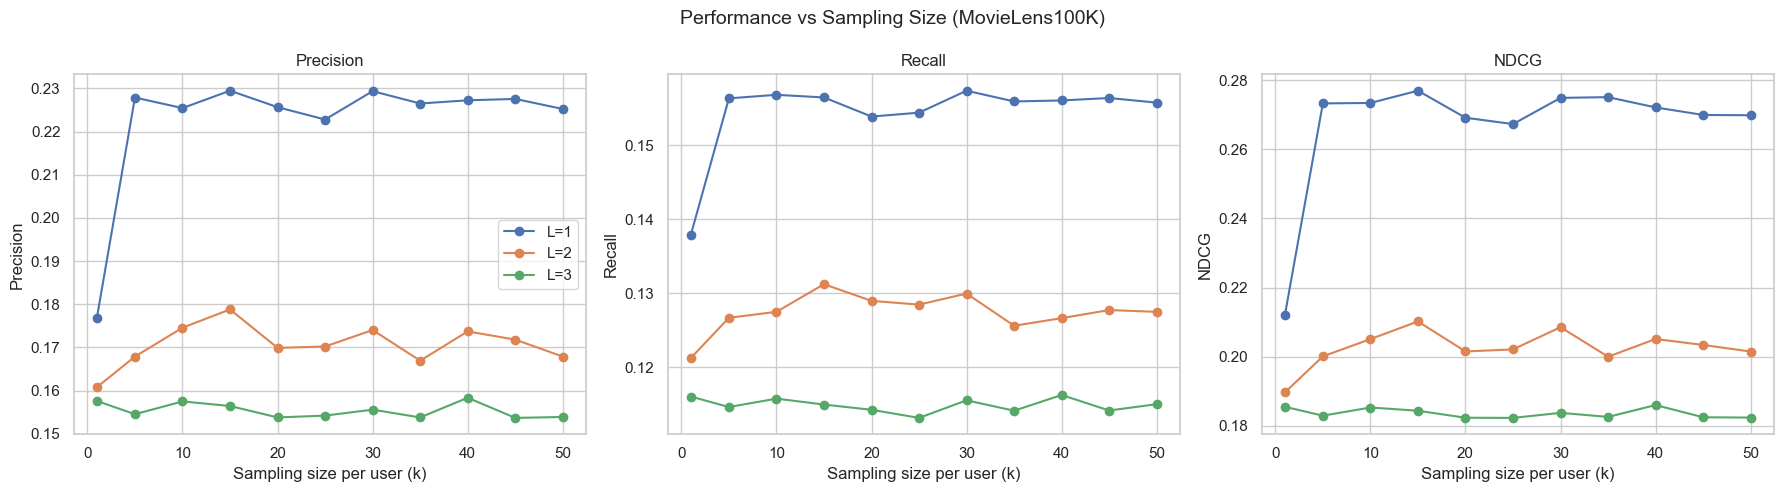

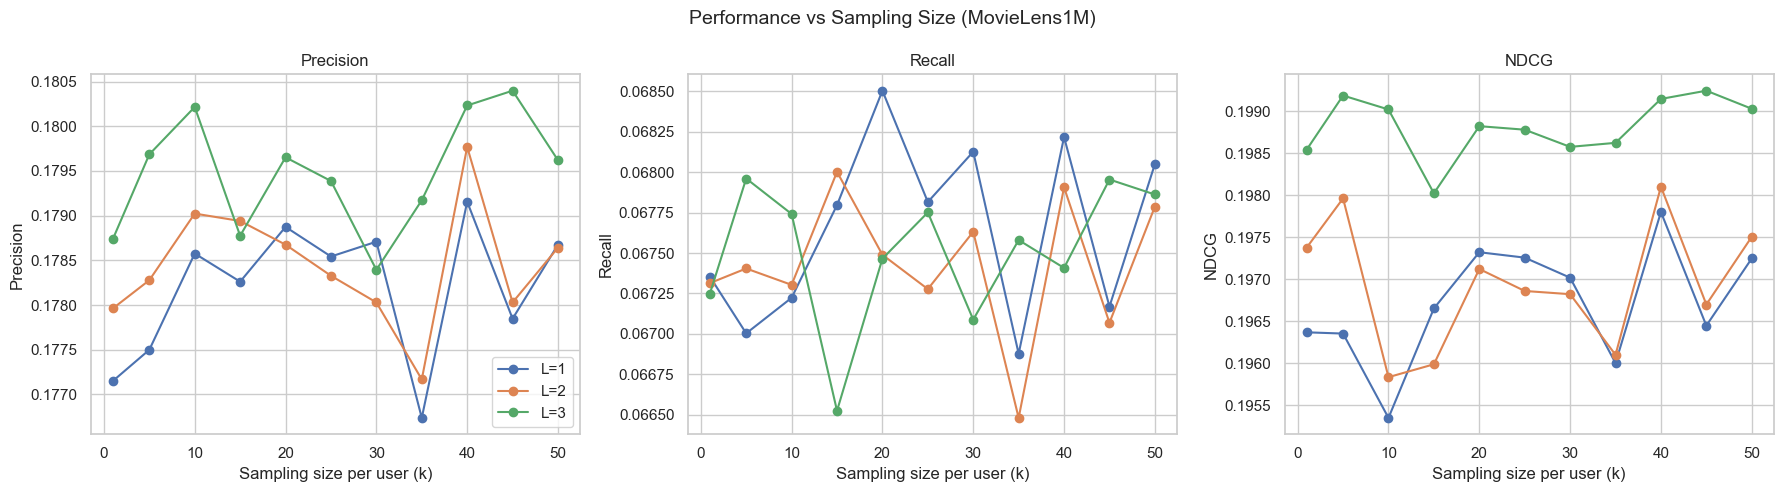

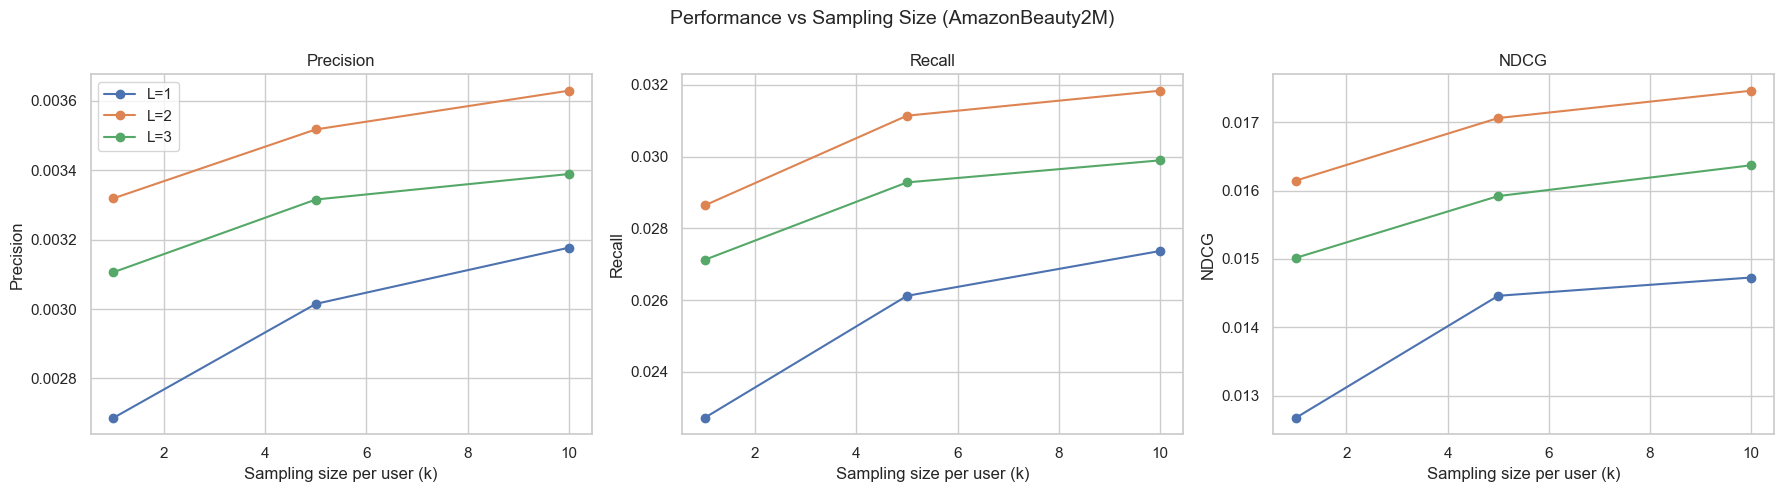

In [10]:
def plot_performance_three_metrics(df_plot, dataset_name=None, save_dir=None):
    # Filter dataset if provided
    if dataset_name is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_name].copy()

    df_plot = df_plot.sort_values(["L", "k"])

    metrics = ["precision", "recall", "ndcg"]
    titles = ["Precision", "Recall", "NDCG"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        for L in sorted(df_plot["L"].unique()):
            subset = df_plot[df_plot["L"] == L].sort_values("k")
            ax.plot(subset["k"], subset[metric], marker="o", label=f"L={L}")

        ax.set_title(titles[idx])
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel(titles[idx])
        ax.grid(True)

    # Only one legend (shared)
    axes[0].legend()

    # Main title
    if dataset_name is not None:
        fig.suptitle(f"Performance vs Sampling Size ({title_map.get(dataset_name, dataset)})", fontsize=14)
    else:
        fig.suptitle("Performance vs Sampling Size", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"{save_dir}\performance_metrics_{dataset_name}.png")
    plt.show()
    plt.close()


# Example:


dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]

for dataset in dataset_order:
    if dataset in df["dataset"].unique():
        plot_performance_three_metrics(df, dataset_name=dataset, save_dir="figures/result_analysis")
        
# for dataset in df["dataset"].unique():
#     plot_performance_three_metrics(df, dataset_name=dataset)

## Time Complexity

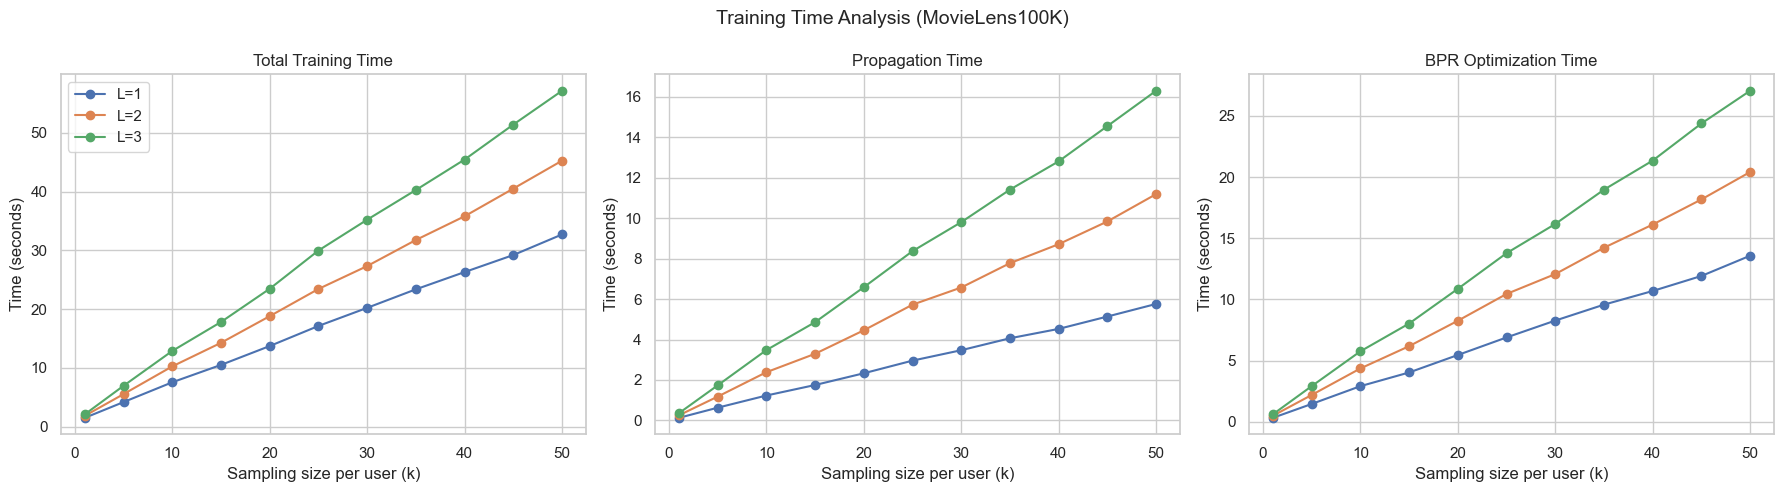

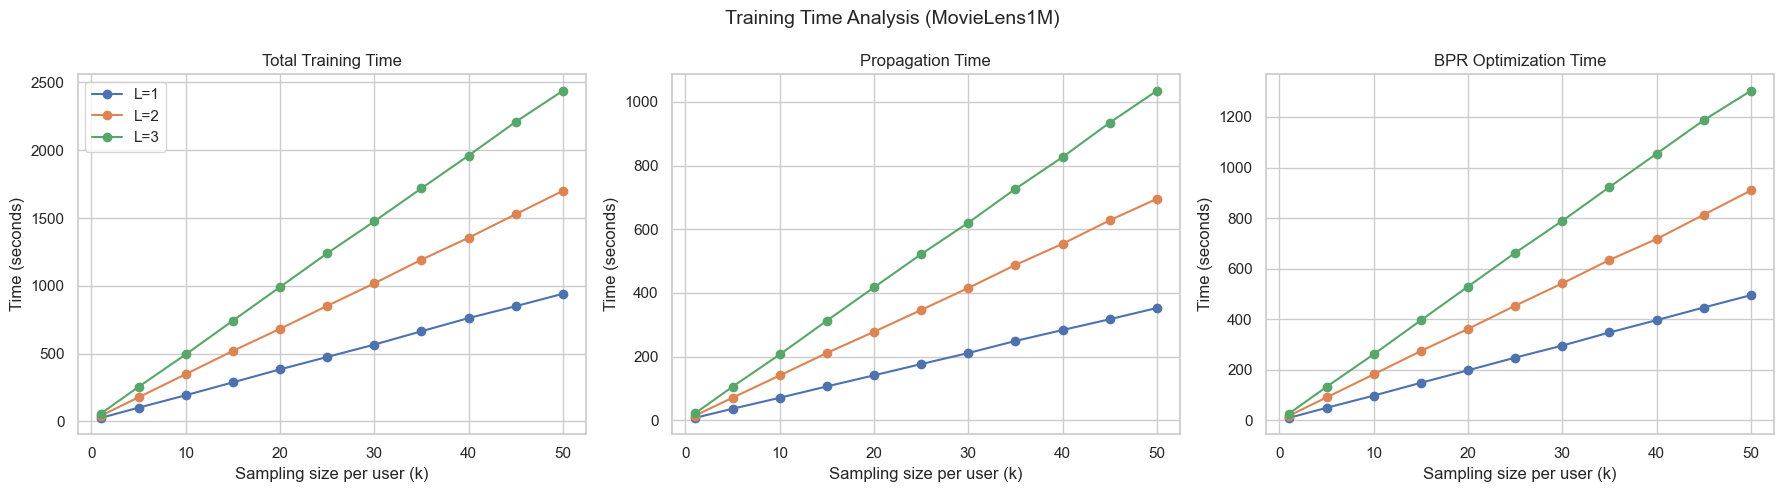

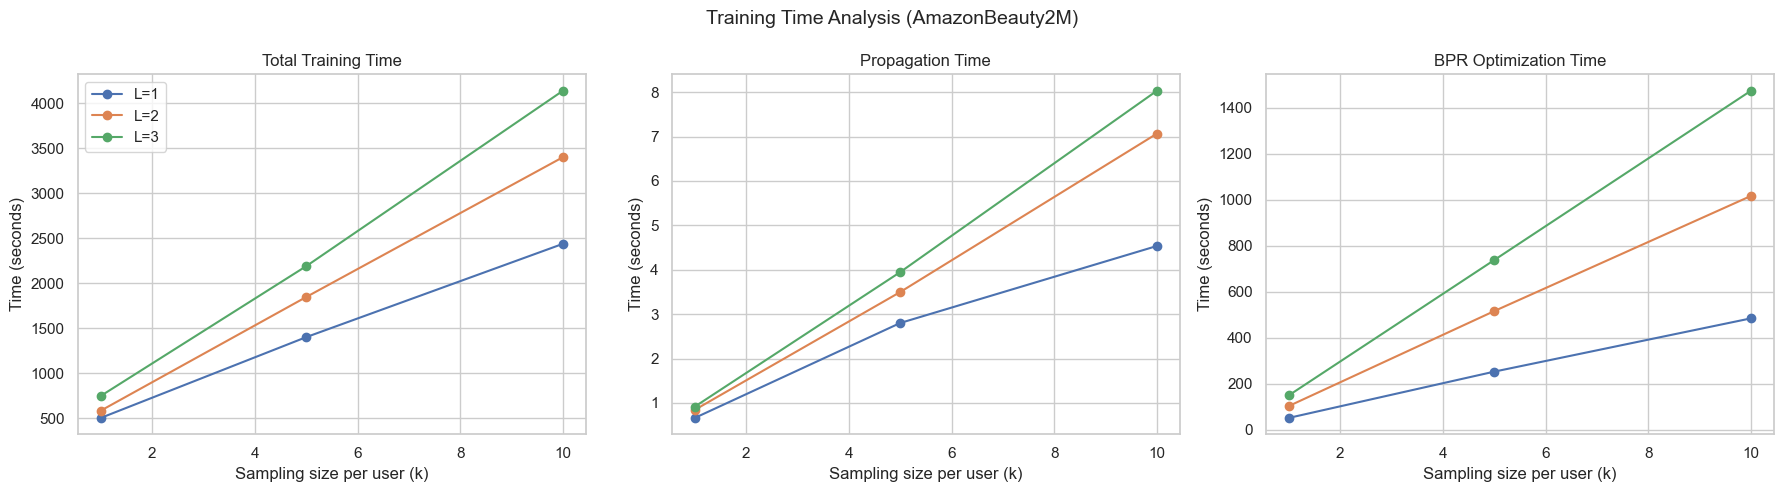

In [12]:
def plot_time_components_three_subfigs(df_plot, dataset_name=None, save_dir=None):
    # Filter dataset
    if dataset_name is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_name].copy()

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    df_plot = df_plot.sort_values(["L", "k"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    components = ["total_time", "prop_time", "bpr_optimization_time"]
    titles = ["Total Training Time", "Propagation Time", "BPR Optimization Time"]

    for idx, comp in enumerate(components):
        ax = axes[idx]

        for L in sorted(df_plot["L"].unique()):
            subset = df_plot[df_plot["L"] == L].sort_values("k")
            ax.plot(subset["k"], subset[comp], marker="o", label=f"L={L}")

        ax.set_title(titles[idx])
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Time (seconds)")
        ax.grid(True)

    # Single legend (clean)
    axes[0].legend()

    # Main title
    if dataset_name is not None:
        fig.suptitle(f"Training Time Analysis ({title_map.get(dataset, dataset)})", fontsize=14)
    else:
        fig.suptitle("Training Time Analysis", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_time_prop_vs_bpr_{dataset_name}.png")
    plt.show()
    plt.close()


dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]

for dataset in dataset_order:
    if dataset in df["dataset"].unique():
        plot_time_components_three_subfigs(df, dataset_name=dataset, save_dir="figures/time_complexity")

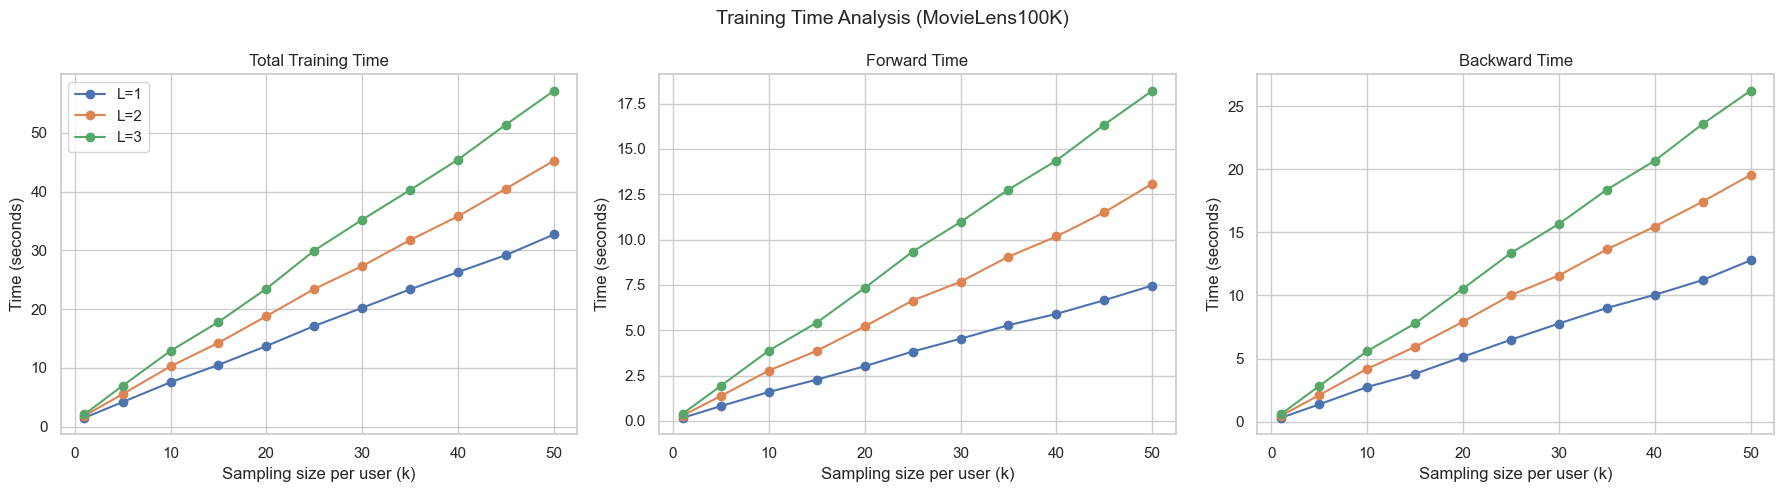

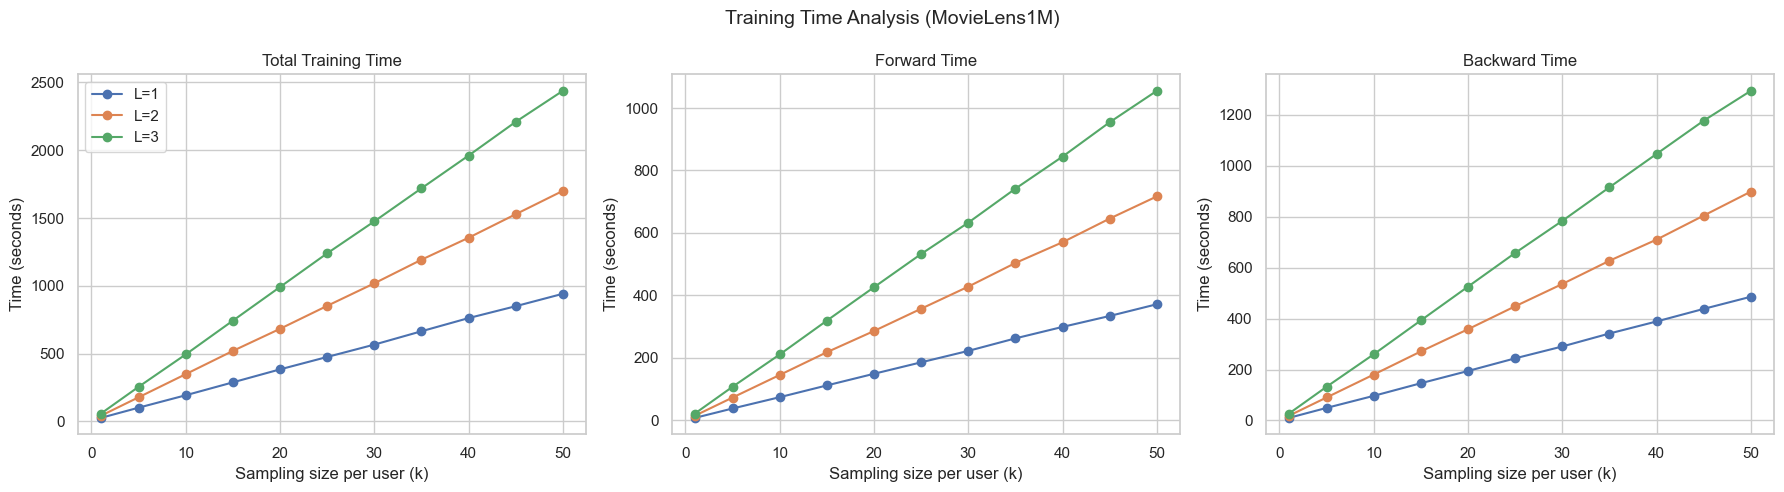

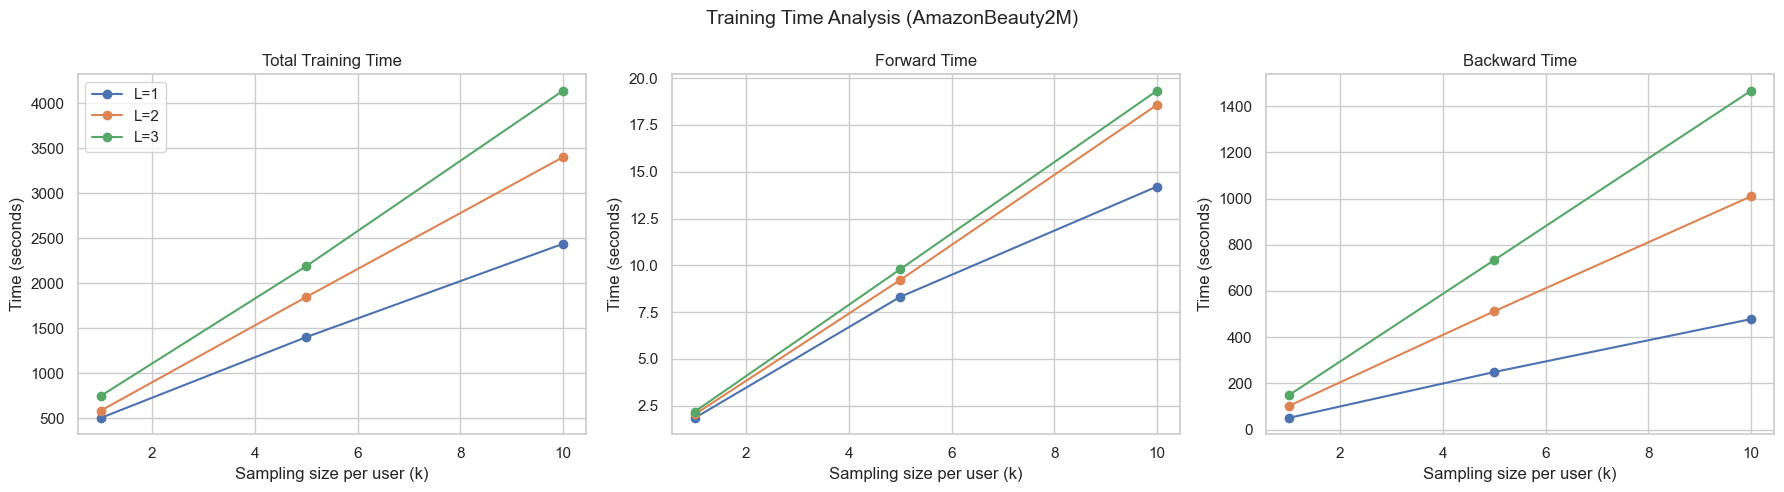

In [13]:
def plot_forward_backward_components_three_subfigs(df_plot, dataset_name=None, save_dir=None):
    # Filter dataset
    if dataset_name is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_name].copy()

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    df_plot = df_plot.sort_values(["L", "k"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    components = ["total_time", "forward_time", "backward_time"]
    titles = ["Total Training Time", "Forward Time", "Backward Time"]

    for idx, comp in enumerate(components):
        ax = axes[idx]

        for L in sorted(df_plot["L"].unique()):
            subset = df_plot[df_plot["L"] == L].sort_values("k")
            ax.plot(subset["k"], subset[comp], marker="o", label=f"L={L}")

        ax.set_title(titles[idx])
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Time (seconds)")
        ax.grid(True)

    # Single legend (clean)
    axes[0].legend()

    # Main title
    if dataset_name is not None:
        fig.suptitle(f"Training Time Analysis ({title_map.get(dataset, dataset)})", fontsize=14)
    else:
        fig.suptitle("Training Time Analysis", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_time_fw_vs_bw_{dataset_name}.png")
    plt.show()
    plt.close()


dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]

for dataset in dataset_order:
    if dataset in df["dataset"].unique():
        plot_forward_backward_components_three_subfigs(df, dataset_name=dataset, save_dir="figures/time_complexity")

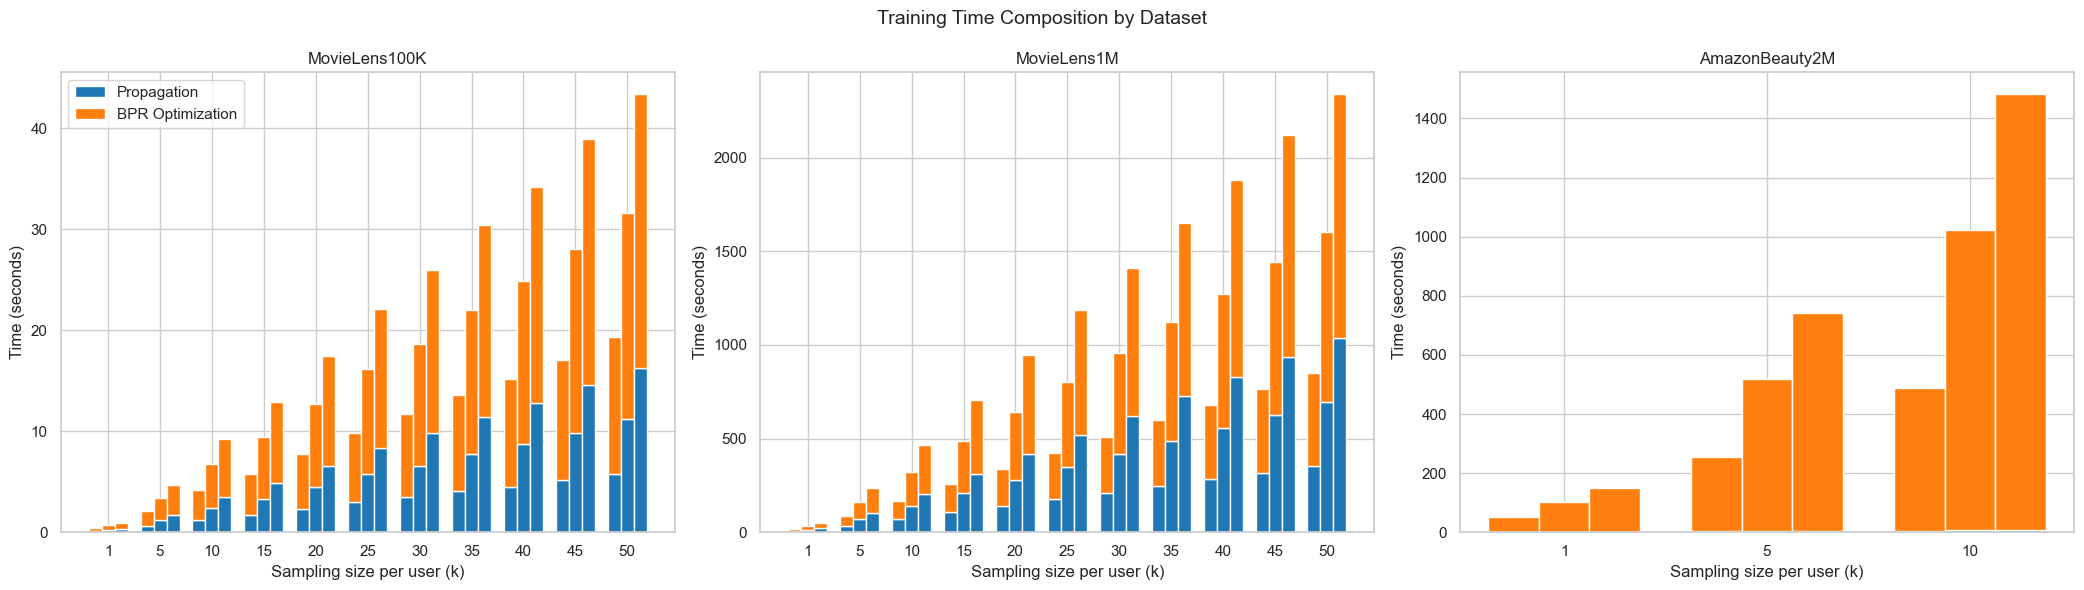

In [ ]:
# =========================================================
# 3. TIME COMPOSITION → Stacked Bar Chart
#    Subfigures for each dataset (ordered)
# =========================================================
def plot_time_composition_stacked_subfigs(df_plot, dataset_order=None, save_dir=None):
    
    # Use custom order if provided, otherwise fallback to sorted
    if dataset_order is not None:
        datasets = [d for d in dataset_order if d in df_plot["dataset"].unique()]
    else:
        datasets = sorted(df_plot["dataset"].unique())

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    n_datasets = len(datasets)

    fig, axes = plt.subplots(1, n_datasets, figsize=(7 * n_datasets, 6), sharey=False)

    if n_datasets == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        subset_dataset = df_plot[df_plot["dataset"] == dataset].copy()

        k_vals = sorted(subset_dataset["k"].unique())
        layers = sorted(subset_dataset["L"].unique())

        x = np.arange(len(k_vals))
        width = 0.25 if len(layers) == 3 else 0.8 / len(layers)

        for i, L in enumerate(layers):
            subset = subset_dataset[subset_dataset["L"] == L].sort_values("k")

            prop = subset["prop_time"].values
            bpr = subset["bpr_optimization_time"].values

            x_pos = x + (i - (len(layers) - 1) / 2) * width

            ax.bar(
                x_pos, prop, width,
                color="tab:blue",
                label="Propagation" if i == 0 else ""
            )
            ax.bar(
                x_pos, bpr, width,
                bottom=prop,
                color="tab:orange",
                label="BPR Optimization" if i == 0 else ""
            )

        ax.set_xticks(x)
        ax.set_xticklabels(k_vals)
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Time (seconds)")
        ax.set_title(title_map.get(dataset, dataset))
        ax.grid(True, axis="y")

    # Shared legend (cleaner than per subplot)
    axes[0].legend()

    fig.suptitle("Training Time Composition by Dataset", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_time_composition_prop_vs_bpr.png")
    plt.show()
    plt.close()

save_dir = None # "figures/result_analysis
dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]
plot_time_composition_stacked_subfigs(df, dataset_order=dataset_order, save_dir=save_dir)

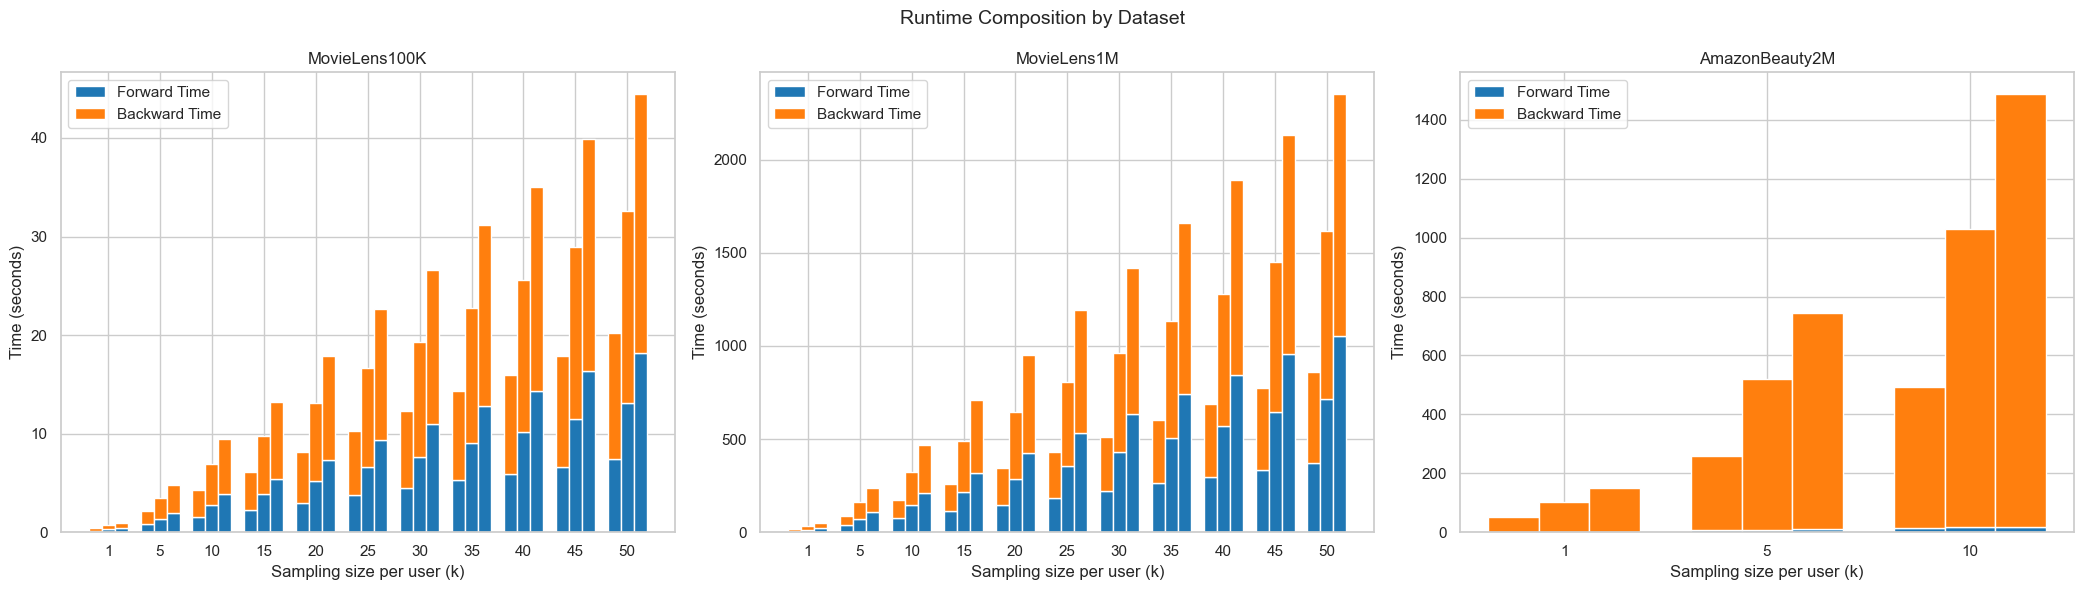

In [10]:
# =========================================================
# 3. TIME COMPOSITION → Stacked Bar Chart
#    Subfigures for each dataset
# =========================================================
def plot_forward_backward_composition_stacked_subfigs(df_plot, dataset_order=None):
    if dataset_order is not None:
        datasets = [d for d in dataset_order if d in df_plot["dataset"].unique()]
    else:
        datasets = sorted(df_plot["dataset"].unique())
    n_datasets = len(datasets)

    fig, axes = plt.subplots(1, n_datasets, figsize=(7 * n_datasets, 6), sharey=False)

    # if only one dataset, axes is not a list
    if n_datasets == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        subset_dataset = df_plot[df_plot["dataset"] == dataset].copy()

        k_vals = sorted(subset_dataset["k"].unique())
        layers = sorted(subset_dataset["L"].unique())

        x = np.arange(len(k_vals))
        width = 0.25 if len(layers) == 3 else 0.8 / len(layers)

        for i, L in enumerate(layers):
            subset = subset_dataset[subset_dataset["L"] == L].sort_values("k")

            fw = subset["forward_time"].values
            bw = subset["backward_time"].values
            eval = subset["eval_time"].values

            x_pos = x + (i - (len(layers) - 1) / 2) * width

            ax.bar(
                x_pos, fw, width,
                color="tab:blue",
                label="Forward Time" if i == 0 else ""
            )
            ax.bar(
                x_pos, bw, width,
                bottom=fw,
                color="tab:orange",
                label="Backward Time" if i == 0 else ""
            )
            # ax.bar(
            #     x_pos, eval, width,
            #     bottom=fw + bw,
            #     color="tab:green",
            #     label="Evaluation Time" if i == 0 else ""
            # )

        ax.set_xticks(x)
        ax.set_xticklabels(k_vals)
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Time (seconds)")
        # ax.set_title(dataset)
        ax.set_title(title_map.get(dataset, dataset))
        ax.grid(True, axis="y")
        ax.legend()

    # shared legend
    # axes[0].legend()

    fig.suptitle("Runtime Composition by Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.close()


# plot_time_composition_stacked_subfigs(df)

dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]
plot_forward_backward_composition_stacked_subfigs(df, dataset_order=dataset_order)

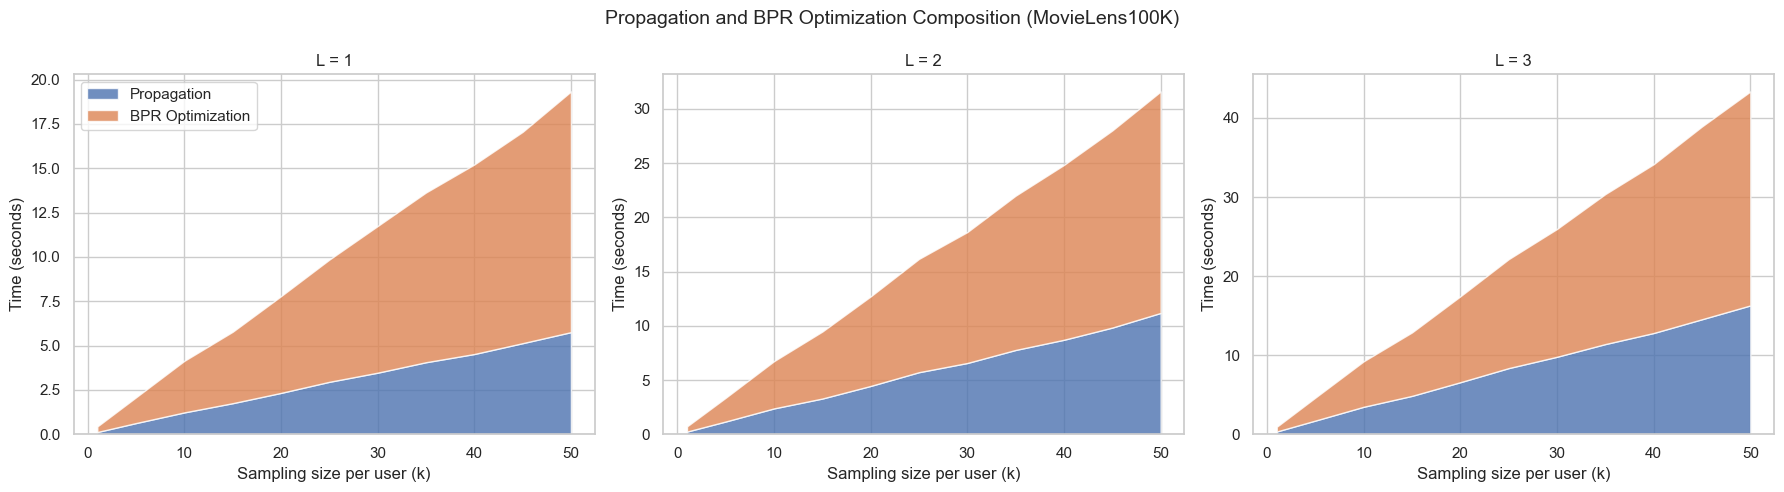

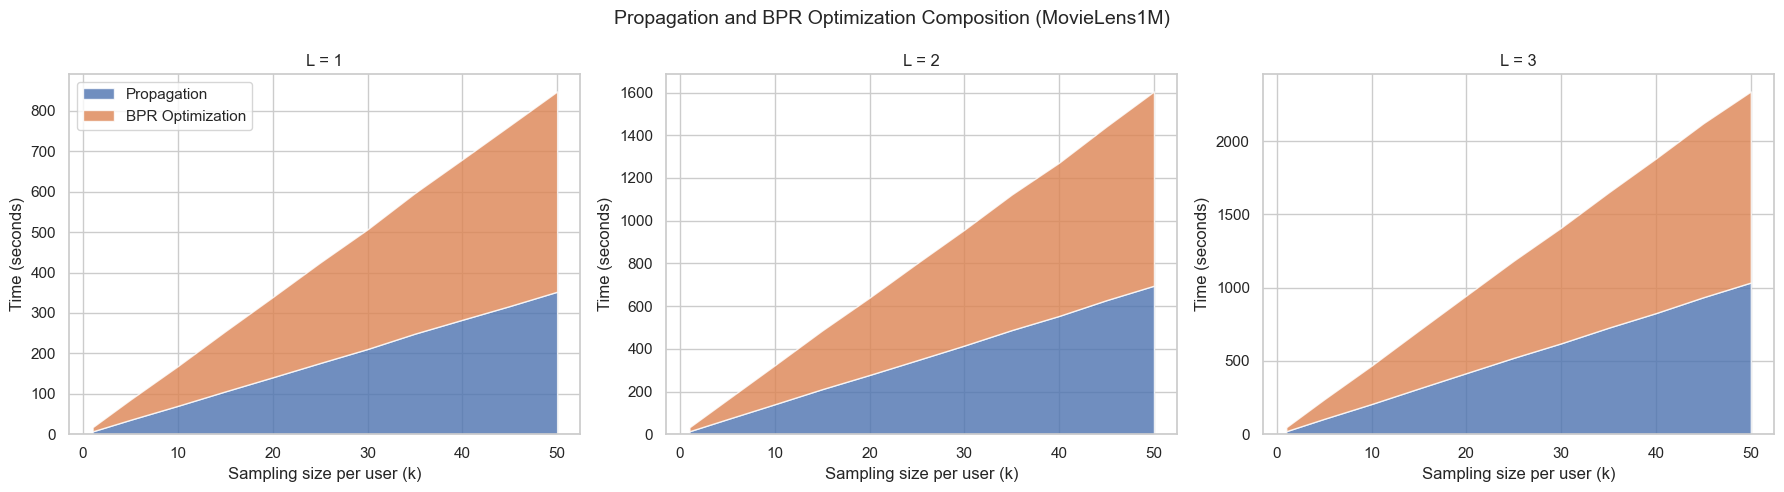

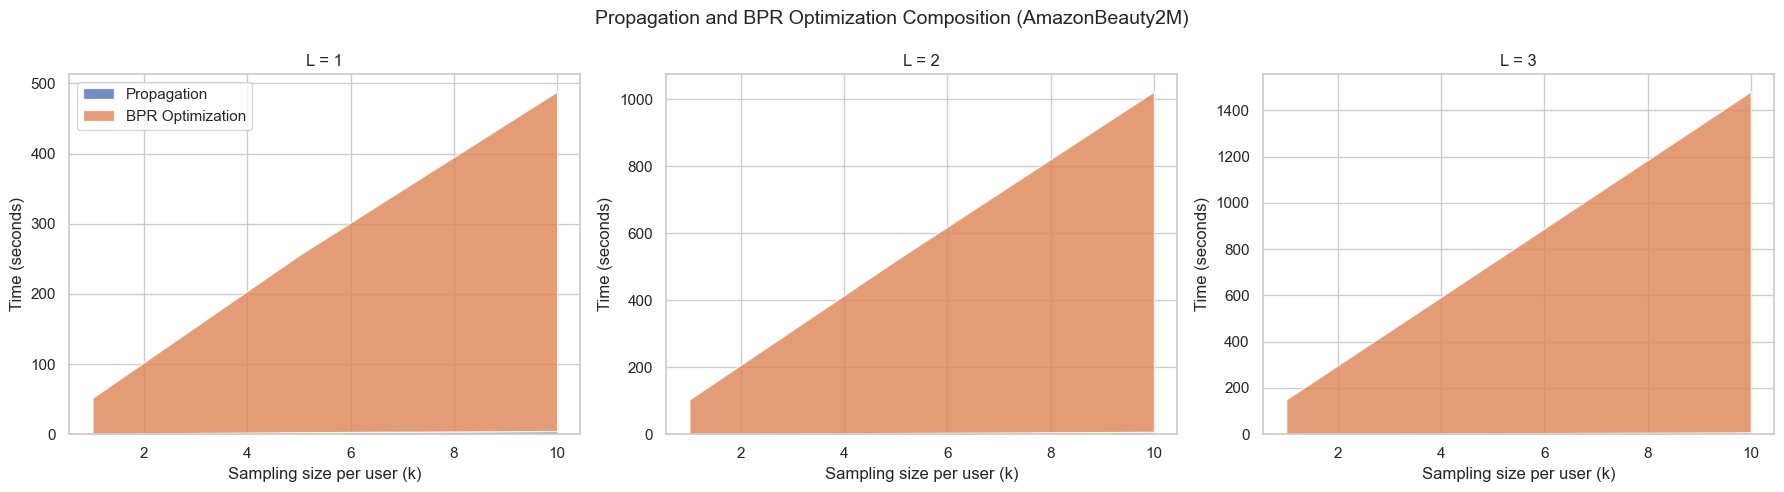

In [14]:
def plot_prop_bpr_area_subfigs(df_plot, dataset_name=None, save_dir=None):
    # Filter dataset if provided
    if dataset_name is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_name].copy()

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    layers = sorted(df_plot["L"].unique())

    fig, axes = plt.subplots(1, len(layers), figsize=(18, 5), sharey=False)

    if len(layers) == 1:
        axes = [axes]

    for idx, L in enumerate(layers):
        ax = axes[idx]
        subset = df_plot[df_plot["L"] == L].sort_values("k")

        ax.stackplot(
            subset["k"],
            subset["prop_time"],
            subset["bpr_optimization_time"],
            labels=["Propagation", "BPR Optimization"],
            alpha=0.8
        )

        ax.set_title(f"L = {L}")
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Time (seconds)")
        ax.grid(True)

    axes[0].legend()

    if dataset_name is not None:
        fig.suptitle(f"Propagation and BPR Optimization Composition ({title_map.get(dataset_name, dataset_name)})", fontsize=14)
    else:
        fig.suptitle("Propagation and BPR Optimization Composition", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/prop_vs_bpr_areachart_{dataset_name}.png")
    plt.show()
    plt.close()


dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]

for dataset in dataset_order:
    if dataset in df["dataset"].unique():
        plot_prop_bpr_area_subfigs(df, dataset_name=dataset, save_dir="figures/time_complexity")

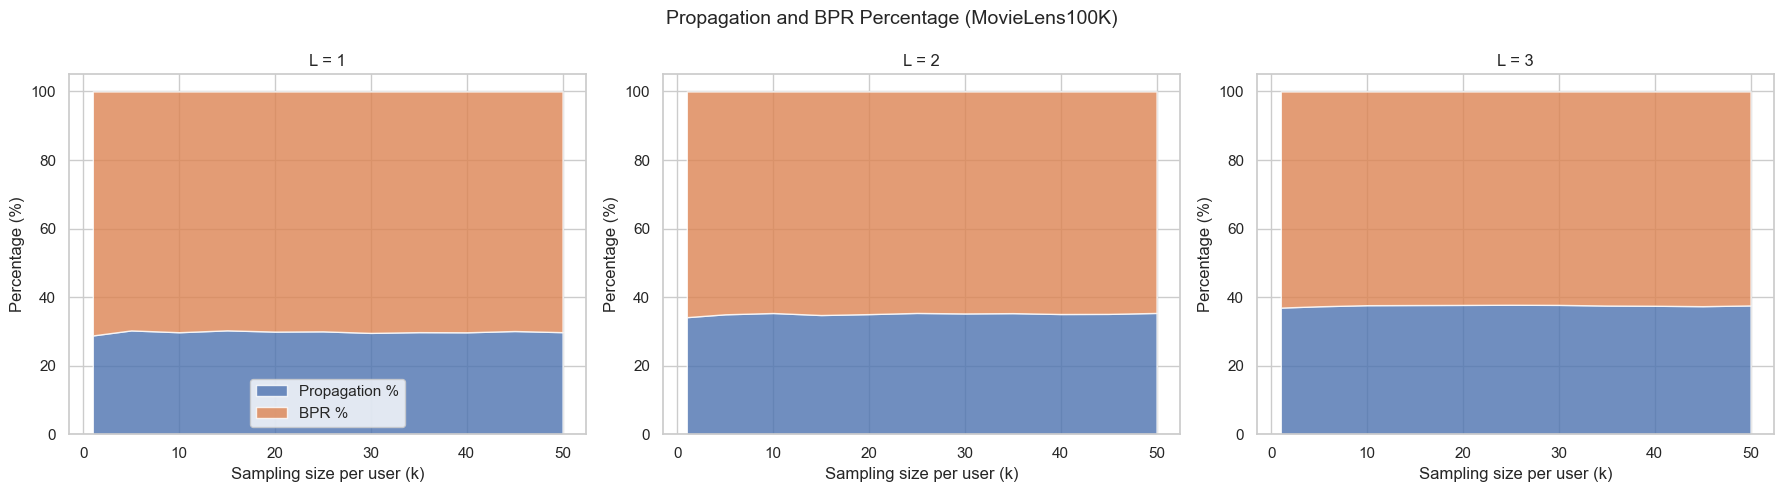

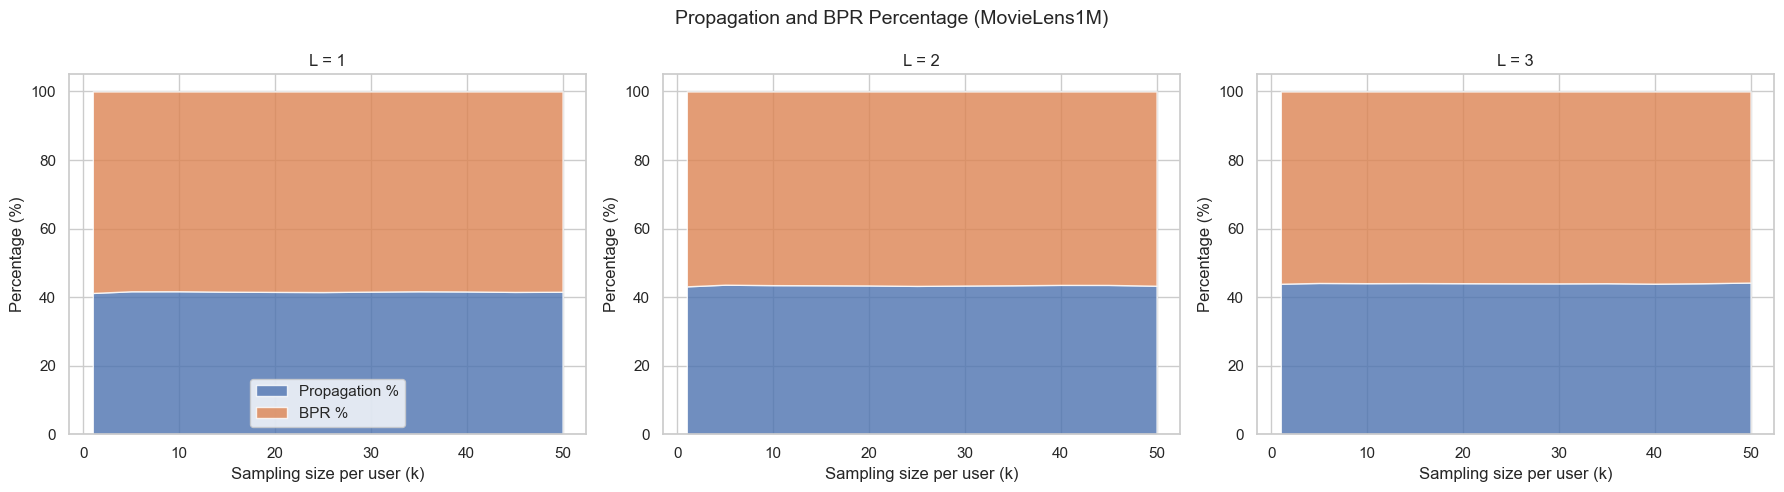

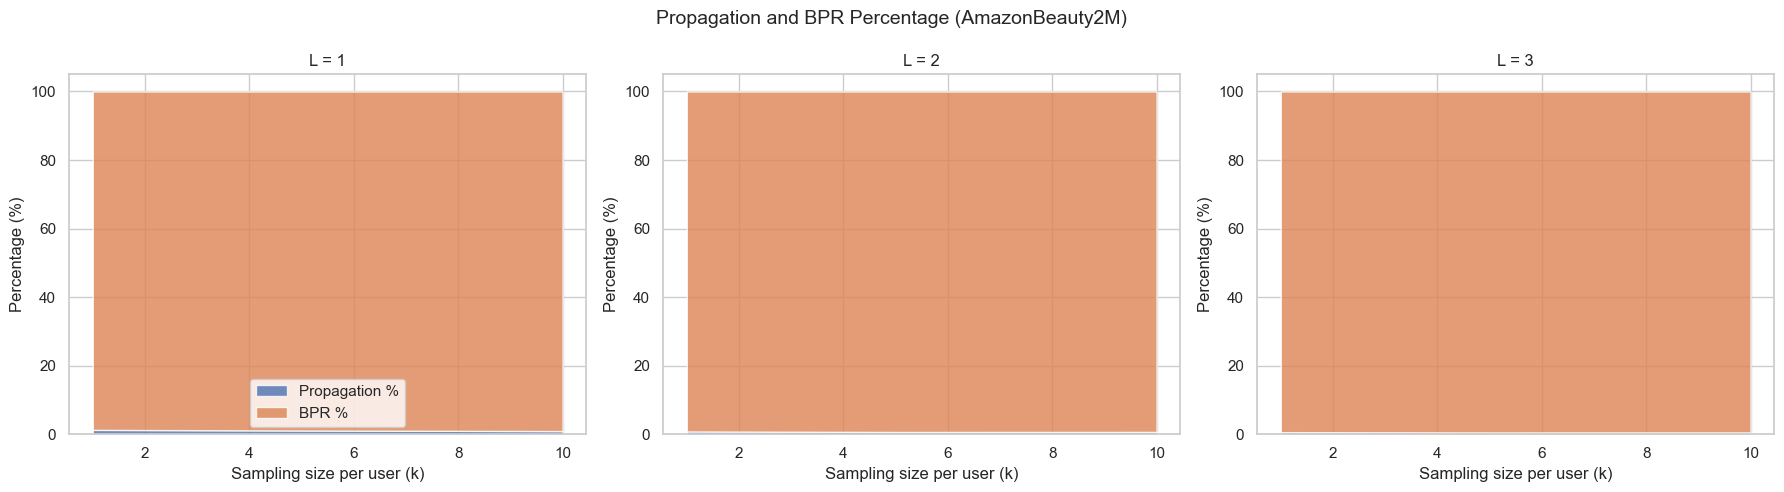

In [12]:
def plot_prop_bpr_area_percentage_subfigs(df_plot, dataset_name=None):
    # Filter dataset if provided
    if dataset_name is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_name].copy()

    layers = sorted(df_plot["L"].unique())

    fig, axes = plt.subplots(1, len(layers), figsize=(18, 5), sharey=False)

    if len(layers) == 1:
        axes = [axes]

    for idx, L in enumerate(layers):
        ax = axes[idx]
        subset = df_plot[df_plot["L"] == L].sort_values("k")

        total = subset["prop_time"] + subset["bpr_optimization_time"]
        prop_pct = subset["prop_time"] / total * 100
        bpr_pct = subset["bpr_optimization_time"] / total * 100

        ax.stackplot(
            subset["k"],
            prop_pct,
            bpr_pct,
            labels=["Propagation %", "BPR %"],
            alpha=0.8
        )

        ax.set_title(f"L = {L}")
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Percentage (%)")
        ax.grid(True)

    axes[0].legend()

    if dataset_name is not None:
        fig.suptitle(f"Propagation and BPR Percentage ({title_map.get(dataset_name, dataset_name)})", fontsize=14)
    else:
        fig.suptitle("Propagation and BPR Percentage", fontsize=14)

    plt.tight_layout()
    plt.show()
    plt.close()


dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]

for dataset in dataset_order:
    if dataset in df["dataset"].unique():
        plot_prop_bpr_area_percentage_subfigs(df, dataset_name=dataset)

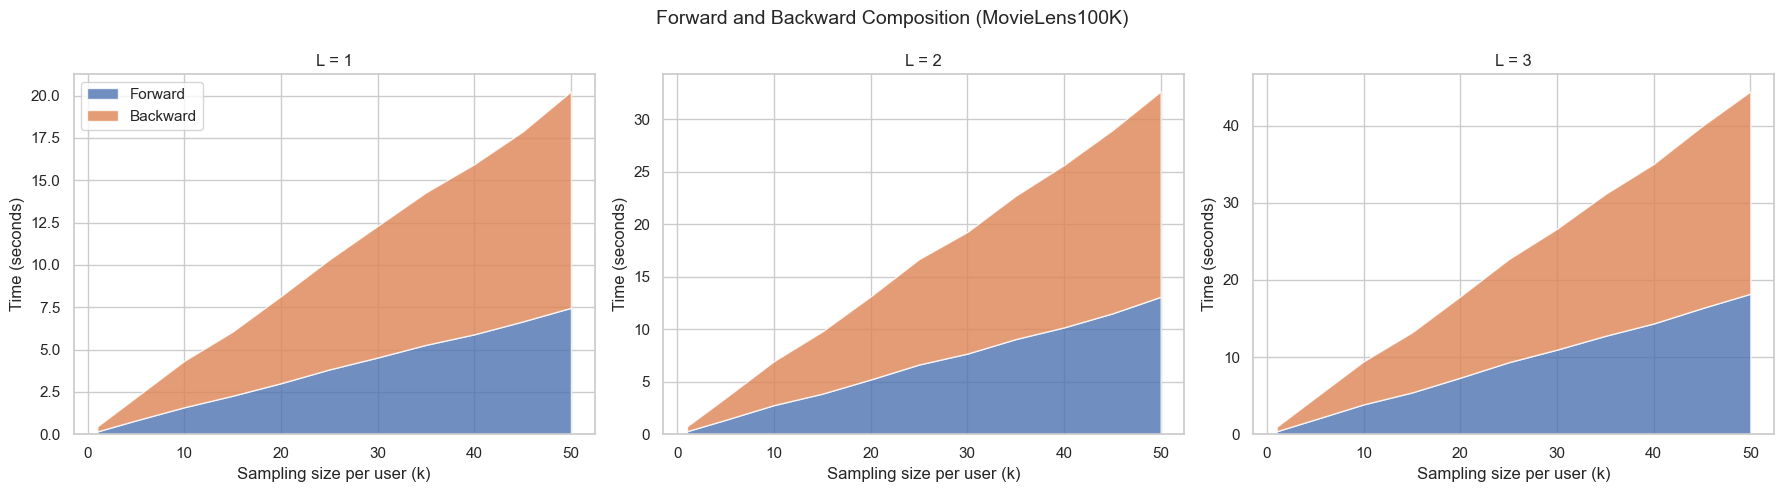

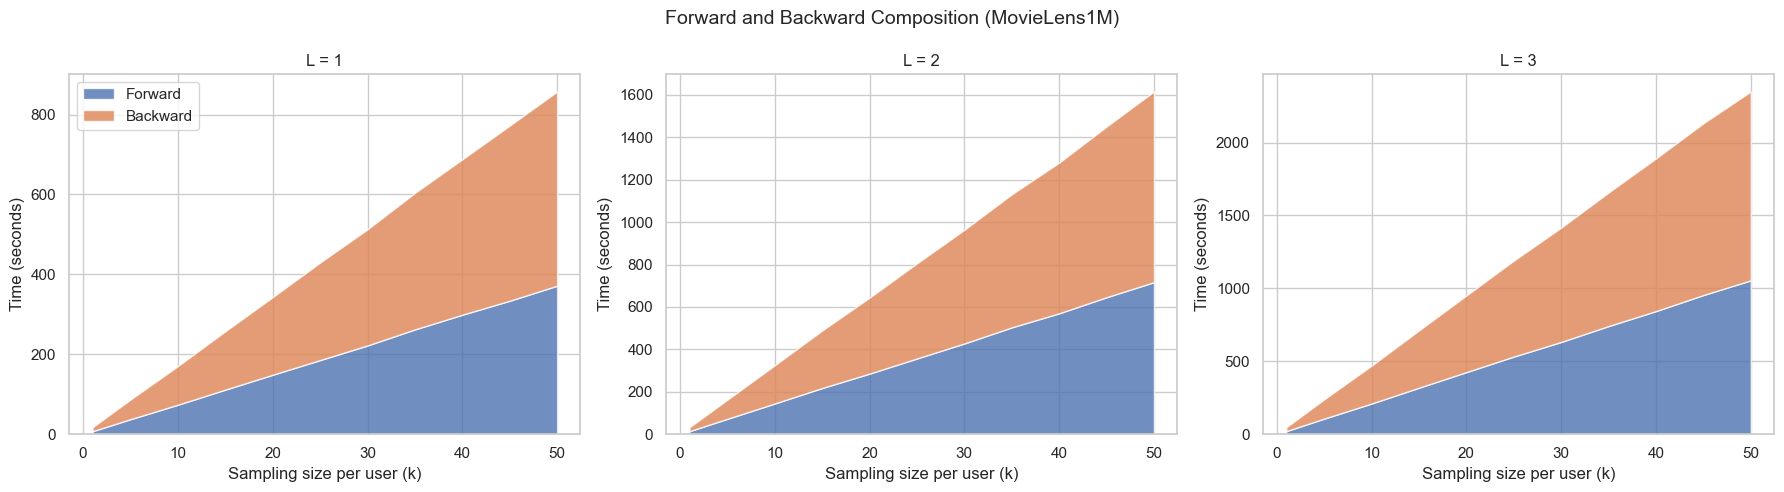

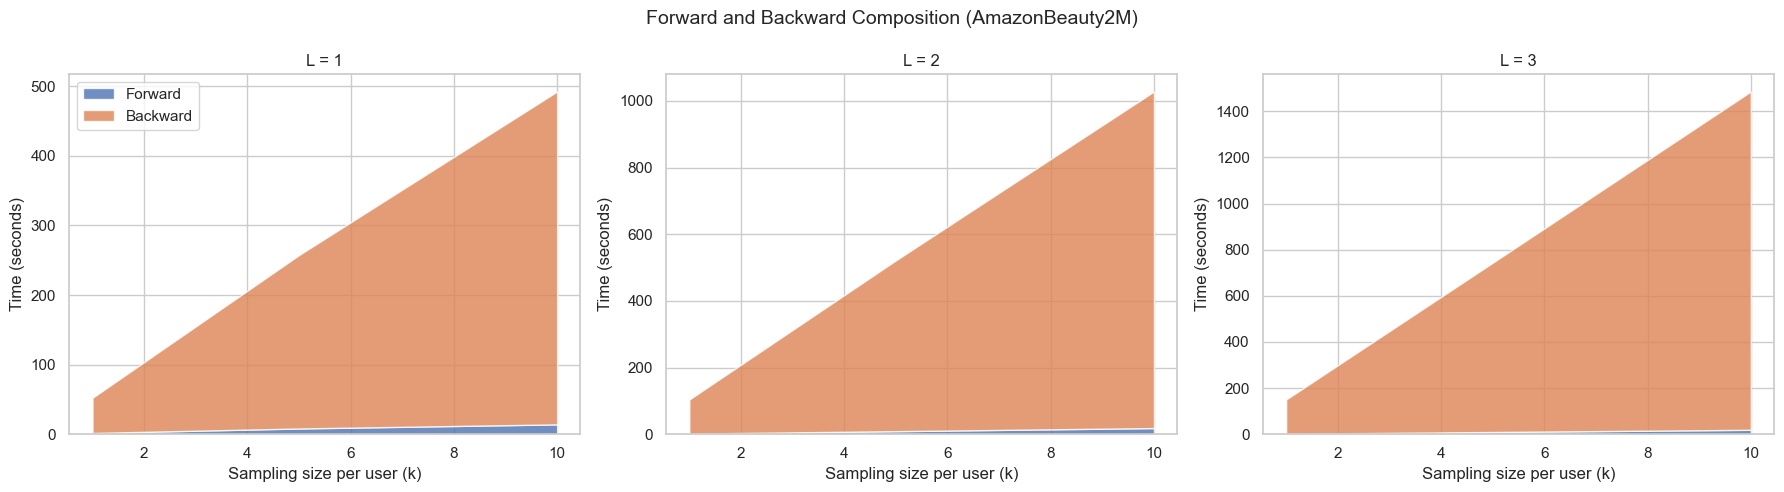

In [15]:
def plot_forward_backward_area_subfigs(df_plot, dataset_name=None, save_dir=None):
    # Filter dataset if provided
    if dataset_name is not None:
        df_plot = df_plot[df_plot["dataset"] == dataset_name].copy()

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    layers = sorted(df_plot["L"].unique())

    fig, axes = plt.subplots(1, len(layers), figsize=(18, 5), sharey=False)

    if len(layers) == 1:
        axes = [axes]

    for idx, L in enumerate(layers):
        ax = axes[idx]
        subset = df_plot[df_plot["L"] == L].sort_values("k")

        ax.stackplot(
            subset["k"],
            subset["forward_time"],
            subset["backward_time"],
            labels=["Forward", "Backward"],
            alpha=0.8
        )

        ax.set_title(f"L = {L}")
        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel("Time (seconds)")
        ax.grid(True)

    axes[0].legend()

    if dataset_name is not None:
        fig.suptitle(f"Forward and Backward Composition ({title_map.get(dataset_name, dataset_name)})", fontsize=14)
    else:
        fig.suptitle("Forward and Backward Composition", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/fw_vs_bw_areachart_{dataset_name}.png")
    plt.show()
    plt.close()


dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]

for dataset in dataset_order:
    if dataset in df["dataset"].unique():
        plot_forward_backward_area_subfigs(df, dataset_name=dataset, save_dir="figures/time_complexity")

## Memory Plot

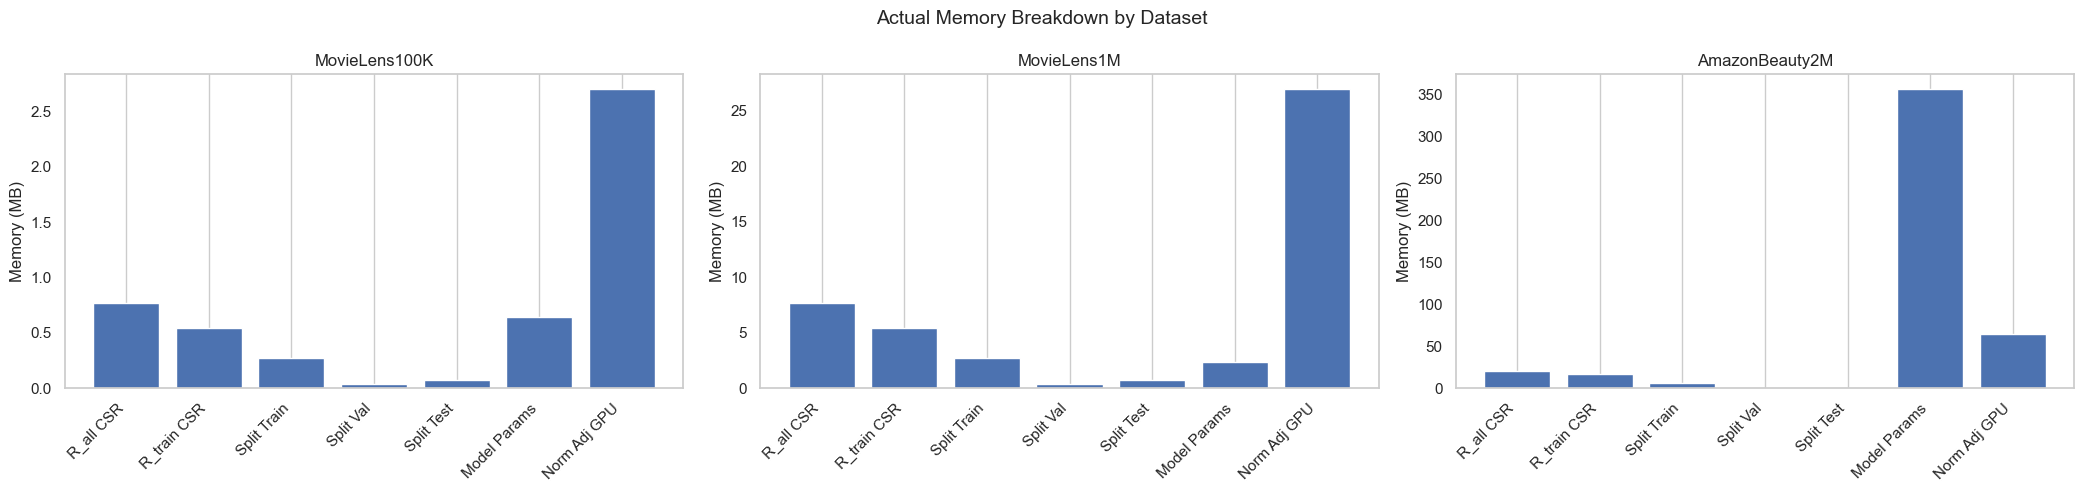

In [16]:
def plot_actual_memory_breakdown_by_dataset(df, dataset_order=None, save_dir=None):
    if dataset_order is None:
        dataset_order = sorted(df["dataset"].unique())

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    datasets = [d for d in dataset_order if d in df["dataset"].unique()]

    components = [
        "R_all_csr_MB",
        "R_train_csr_MB",
        "split_train_MB",
        "split_val_MB",
        "split_test_MB",
        "model_params_MB",
        "norm_adj_gpu_MB",
    ]

    component_labels = {
        "R_all_csr_MB": "R_all CSR",
        "R_train_csr_MB": "R_train CSR",
        "split_train_MB": "Split Train",
        "split_val_MB": "Split Val",
        "split_test_MB": "Split Test",
        "model_params_MB": "Model Params",
        "norm_adj_gpu_MB": "Norm Adj GPU",
    }

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=False)

    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        subset = df[df["dataset"] == dataset]

        # average across all runs for this dataset
        mean_vals = subset[components].mean()

        x = np.arange(len(components))
        ax.bar(x, mean_vals.values)

        ax.set_xticks(x)
        ax.set_xticklabels([component_labels[c] for c in components], rotation=45, ha="right")
        ax.set_ylabel("Memory (MB)")
        ax.set_title(title_map.get(dataset, dataset))
        ax.grid(axis="y")

    fig.suptitle("Actual Memory Breakdown by Dataset", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/actual_memory_breakdown.png")
    plt.show()
    plt.close()


# dataset_order = ["movielens100k", "movielens1m", "amazonBeauty2m"]
plot_actual_memory_breakdown_by_dataset(df, dataset_order=dataset_order, save_dir="figures/memory_complexity")

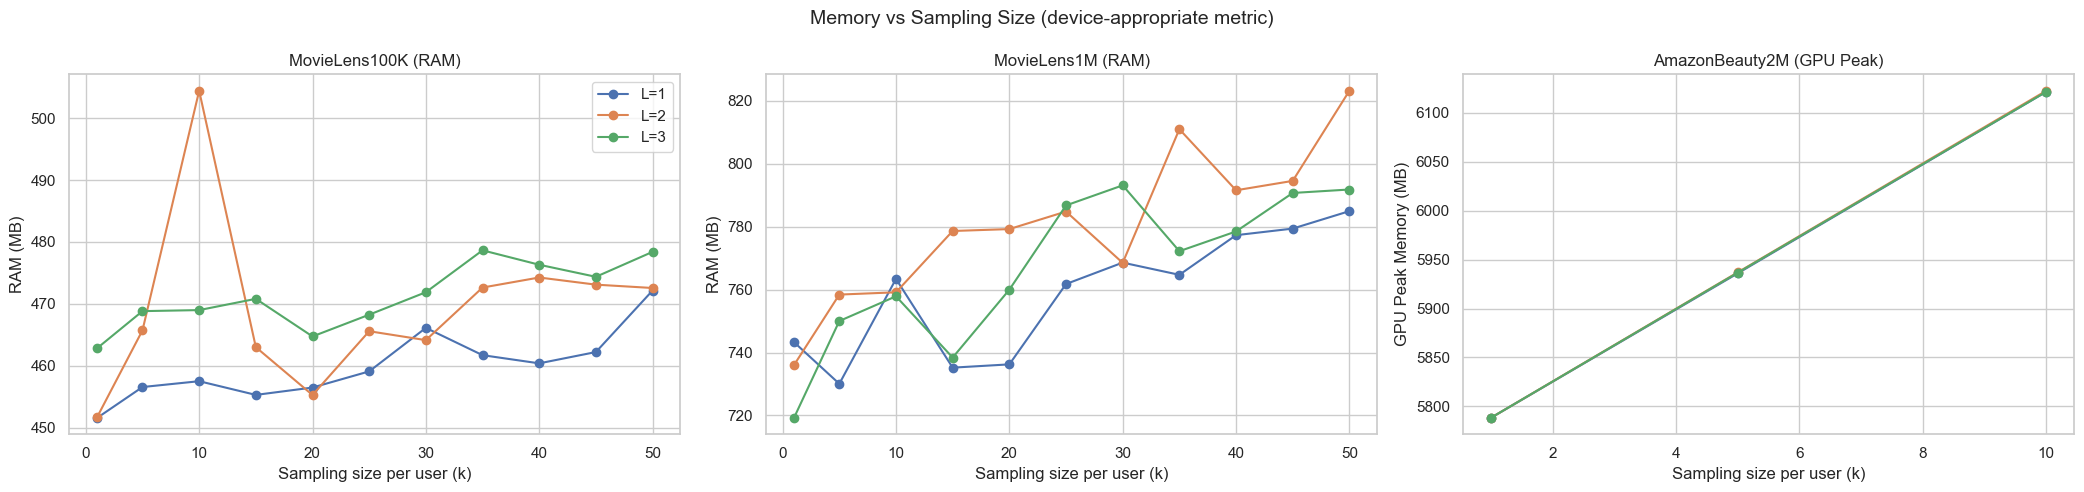

In [ ]:
def add_run_level_ram_from_epoch_log(df):
    df = df.copy()

    def mean_ram(epoch_log):
        if not isinstance(epoch_log, list) or len(epoch_log) == 0:
            return np.nan
        vals = [e.get("ram_mb", np.nan) for e in epoch_log]
        vals = [v for v in vals if pd.notna(v)]
        return np.mean(vals) if len(vals) > 0 else np.nan

    def max_ram(epoch_log):
        if not isinstance(epoch_log, list) or len(epoch_log) == 0:
            return np.nan
        vals = [e.get("ram_mb", np.nan) for e in epoch_log]
        vals = [v for v in vals if pd.notna(v)]
        return np.max(vals) if len(vals) > 0 else np.nan

    df["ram_mean_MB"] = df["epoch_log"].apply(mean_ram)
    df["ram_max_MB"] = df["epoch_log"].apply(max_ram)

    return df


def plot_memory_vs_k_mixed_device(df, dataset_order=None, save_dir=None):
    if dataset_order is None:
        dataset_order = sorted(df["dataset"].unique())

    if save_dir != None:
        os.makedirs(save_dir, exist_ok=True)

    datasets = [d for d in dataset_order if d in df["dataset"].unique()]

    fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=False)

    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        subset_dataset = df[df["dataset"] == dataset].copy()

        for L in sorted(subset_dataset["L"].unique()):
            subset = subset_dataset[subset_dataset["L"] == L].sort_values("k")

            # CPU datasets -> RAM, GPU dataset -> GPU peak
            if dataset in ["movielens100k", "movielens1m"]:
                y = subset["ram_mean_MB"]
                ylabel = "RAM (MB)"
                title_suffix = "RAM"
            else:
                y = subset["gpu_peak_MB"]
                ylabel = "GPU Peak Memory (MB)"
                title_suffix = "GPU Peak"

            ax.plot(
                subset["k"],
                y,
                marker="o",
                label=f"L={L}"
            )

        ax.set_xlabel("Sampling size per user (k)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title_map.get(dataset, dataset)} ({title_suffix})")
        ax.grid(True)

    axes[0].legend()
    fig.suptitle("Memory vs Sampling Size (device-appropriate metric)", fontsize=14) # Average per epoch
    plt.tight_layout()
    plt.savefig(f"{save_dir}/memory_vs_sampling_size.png")
    plt.show()
    plt.close()


df_mem = add_run_level_ram_from_epoch_log(df)
plot_memory_vs_k_mixed_device(df_mem, dataset_order=dataset_order, save_dir="figures/memory_complexity")